## Exploaration de données 

📂 Dossier de recherche : c:\Users\louni\projetEtudeM2\smart-mobility-paris-m2-project\data
✅ Fichier trouvé ! Chargement en cours...

--- DIMENSIONS ---
8784 lignes, 9 colonnes

--- STATISTIQUES DES POLLUANTS ---


,Chap-Bagn,Bagn-Berc,Berc-Ital,Ital-A6a,A6a-Sevr,Sevr-Aute,Aute-Mail,Mail-Chap
count,8616.000000,8616.000000,8616.000000,8616.000000,8616.000000,8616.000000,8616.000000,8616.000000
mean,37.877205,46.021007,40.308380,31.300952,32.762767,32.431523,40.185121,37.296890
std,16.053046,18.572314,16.852767,14.616096,16.172902,15.589107,17.213931,17.195657
min,5.000000,5.000000,4.000000,0.000000,0.000000,2.000000,4.000000,4.000000
25%,26.000000,32.000000,28.000000,21.000000,21.000000,21.000000,27.000000,25.000000
50%,37.000000,45.000000,39.000000,29.000000,30.000000,30.000000,39.000000,35.000000
75%,48.000000,58.000000,50.000000,39.000000,42.000000,41.000000,51.000000,47.250000
max,114.000000,159.000000,129.000000,108.000000,133.000000,134.000000,136.000000,136.000000


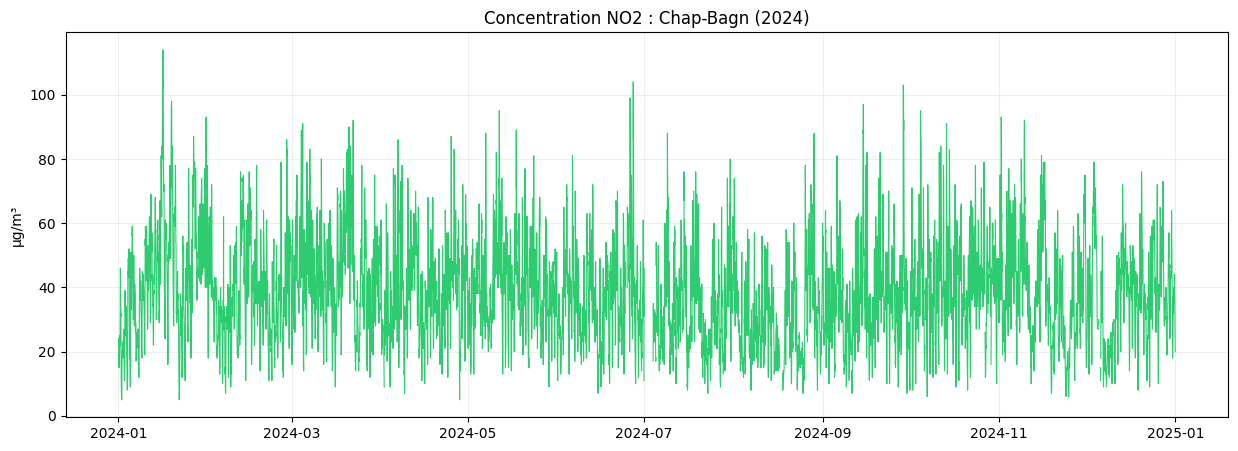

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from pathlib import Path

# =============================================================
# 1. NAVIGATION DYNAMIQUE DES CHEMINS
# =============================================================
# On récupère l'emplacement actuel (le dossier 'notebooks')
current_dir = Path(os.getcwd())

# Si on est dans 'notebooks', on remonte au parent pour trouver 'data'
if current_dir.name == 'notebooks':
    base_path = current_dir.parent
else:
    base_path = current_dir

data_dir = base_path / 'data'
file_name = '2024_NO2_boulevard_périphérique.csv'
file_path = data_dir / file_name

print(f"📂 Dossier de recherche : {data_dir.absolute()}")

# =============================================================
# 2. VÉRIFICATION ET CHARGEMENT
# =============================================================
if not file_path.exists():
    print(f"❌ Erreur : Le fichier '{file_name}' est introuvable.")
    print(f"🔍 Contenu actuel du dossier data :")
    try:
        for f in data_dir.iterdir():
            print(f"  - {f.name}")
    except FileNotFoundError:
        print("  - [Le dossier 'data' lui-même est introuvable à cette adresse]")
else:
    print(f"✅ Fichier trouvé ! Chargement en cours...")
    # engine='python' aide souvent avec les accents dans les noms de fichiers
    df = pd.read_csv(file_path, sep=",", engine='python')
    df['time'] = pd.to_datetime(df['time'], errors='coerce')
    
    # --- Premières stats ---
    print("\n--- DIMENSIONS ---")
    print(f"{df.shape[0]} lignes, {df.shape[1]} colonnes")
    
    print("\n--- STATISTIQUES DES POLLUANTS ---")
    # On exclut la colonne 'time' pour les stats numériques
    display(df.drop(columns=['time']).describe())

    # =============================================================
    # 3. VISUALISATION RAPIDE
    # =============================================================
    plt.figure(figsize=(15, 5))
    # On prend un segment au hasard (ex: Porte de la Chapelle vers Bagnolet)
    plt.plot(df['time'], df['Chap-Bagn'], color='#2ecc71', linewidth=0.8)
    plt.title(f"Concentration NO2 : Chap-Bagn (2024)")
    plt.ylabel("µg/m³")
    plt.grid(True, alpha=0.2)
    plt.show()

    # 1. Afficher les types de données pour chaque colonne
    print("--- TYPES DES COLONNES ---")
    print(df.dtypes)

    print("\n" + "="*30 + "\n")

    # 2. Afficher le nombre de valeurs nulles (NaN) pour chaque colonne
    print("--- NOMBRE DE VALEURS NULLES ---")
    null_counts = df.isnull().sum()
    print(null_counts)

    #Afficher le pourcentage de valeurs manquantes (plus parlant)
    print("\n--- POURCENTAGE DE VALEURS NULLES ---")
    print((df.isnull().sum() / len(df)) * 100)

    